# Exploring Hamilton DAGs with iacs Data

Hamilton is a framework for defining dataflows (DAGs) using plain Python functions:
- **Function names** become node names
- **Parameter names** declare dependencies on other nodes
- The DAG is constructed lazily — nothing executes until you call `driver.execute()`

Here we define a small Hamilton dataflow over iacs registry tables and visualize the DAG.

In [1]:
import ibis
from hamilton import driver, base
from iacs.dataflows import load_manifest, validate_registry
from iacs.dataflows.audit import requirement_coverage

ibis.options.interactive = True

In [2]:
target_module = validate_registry

In [3]:
import importlib
importlib.reload(target_module)

<module 'iacs.dataflows.validate_registry' from '/Users/zhafen/repos/iacs/iacs/dataflows/validate_registry.py'>

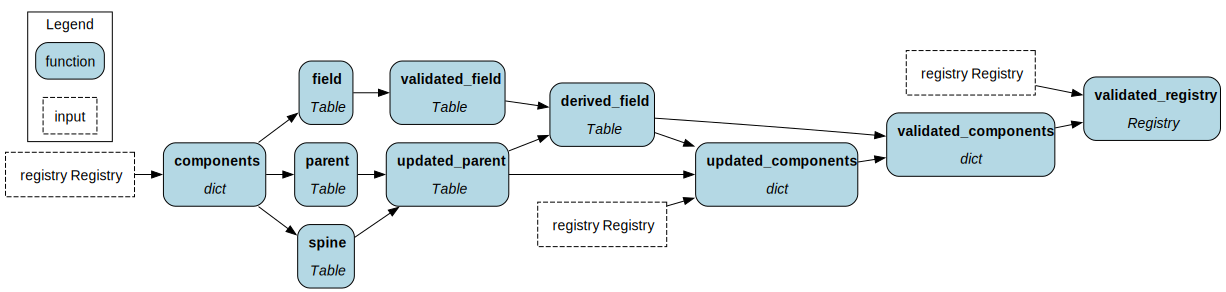

In [4]:
config = {}
dr = driver.Driver(config, target_module)
dr

## Execute the DAG

In [ ]:
result = dr.execute(["entity_summary", "root_entities", "entity_child_count"])

In [ ]:
result["entity_summary"]

In [ ]:
result["root_entities"]

In [ ]:
result["entity_child_count"]

## Visualize execution

Show which nodes were traversed to compute `root_entities`.

In [ ]:
dr.visualize_execution(["root_entities"], "./hamilton_execution.png", {"format": "png"})